In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Install dowhy
import sys
!{sys.executable} -m pip install dowhy -q

import dowhy
from dowhy import CausalModel

# Load data
df = pd.read_csv('../data/processed/final_features.csv')

print("✅ DoWhy loaded")
print(f"Dataset shape: {df.shape}")

✅ DoWhy loaded
Dataset shape: (51336, 27)


✅ Causal model built

Causal Graph:


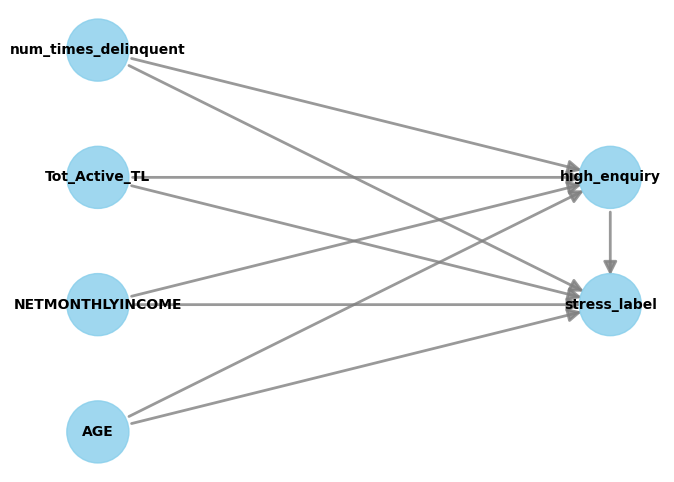

In [2]:
# ── CAUSAL GRAPH DEFINITION ───────────────────────────────────────
# We define the causal relationships between variables
# based on domain knowledge of MSME credit markets
#
# Causal story:
# - Financial stress CAUSES firms to make more enquiries (not other way)
# - Age and income are common causes (confounders)
# - Delinquency history causes both enquiry acceleration AND stress
#
# Key question we want to answer:
# "Does high enquiry_acceleration CAUSALLY increase stress risk,
#  or is it just correlated because both are caused by something else?"

# Create binary treatment variable
df['high_enquiry'] = (
    df['enquiry_acceleration'] > df['enquiry_acceleration'].median()
).astype(int)

# Build causal model
model = CausalModel(
    data=df,
    treatment='high_enquiry',
    outcome='stress_label',
    common_causes=[
        'AGE',
        'NETMONTHLYINCOME',
        'num_times_delinquent',
        'Tot_Active_TL'
    ],
    instruments=None
)

print("✅ Causal model built")
print("\nCausal Graph:")
model.view_model()

In [3]:
# ── IDENTIFY CAUSAL EFFECT ────────────────────────────────────────
print("Step 1: Identifying causal effect...")
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

# ── ESTIMATE CAUSAL EFFECT ────────────────────────────────────────
print("\nStep 2: Estimating causal effect...")

# Method 1 — Backdoor linear regression
estimate_lr = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    control_value=0,
    treatment_value=1,
    confidence_intervals=True
)
print(f"\n=== LINEAR REGRESSION ESTIMATE ===")
print(f"Causal effect: {estimate_lr.value:.4f}")
print(f"This means: high enquiry acceleration increases")
print(f"stress probability by {estimate_lr.value*100:.1f} percentage points")
print(f"after controlling for age, income, delinquency history")

Step 1: Identifying causal effect...
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
───────────────(E[stress_label|NETMONTHLYINCOME,AGE,Tot_Active_TL,num_times_de ↪
d[high_enquiry]                                                                ↪

↪           
↪ linquent])
↪           
Estimand assumption 1, Unconfoundedness: If U→{high_enquiry} and U→stress_label then P(stress_label|high_enquiry,NETMONTHLYINCOME,AGE,Tot_Active_TL,num_times_delinquent,U) = P(stress_label|high_enquiry,NETMONTHLYINCOME,AGE,Tot_Active_TL,num_times_delinquent)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                                                       ↪
───────────────(E[stress_

In [4]:
# ── REFUTATION TESTS ──────────────────────────────────────────────
# Refutation tests check if our causal estimate is robust
# If the estimate holds under these tests, it's genuine causation
# If it breaks, it was just correlation

print("Step 3: Running refutation tests...")
print("(These verify the causal estimate is genuine)\n")

# Test 1 — Random common cause
# Add a random variable as a confounder
# If estimate changes a lot, our model is fragile
print("Test 1: Random Common Cause Refuter")
refute1 = model.refute_estimate(
    identified_estimand, estimate_lr,
    method_name="random_common_cause",
    random_seed=42
)
print(refute1)

# Test 2 — Placebo treatment
# Replace treatment with random noise
# Estimated effect should drop to near zero
print("\nTest 2: Placebo Treatment Refuter")
refute2 = model.refute_estimate(
    identified_estimand, estimate_lr,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    random_seed=42
)
print(refute2)

# Test 3 — Data subset refuter
# Run on random 80% subset of data
# Estimate should stay similar if robust
print("\nTest 3: Data Subset Refuter")
refute3 = model.refute_estimate(
    identified_estimand, estimate_lr,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    random_seed=42
)
print(refute3)

Step 3: Running refutation tests...
(These verify the causal estimate is genuine)

Test 1: Random Common Cause Refuter
Refute: Add a random common cause
Estimated effect:0.28685694553581004
New effect:0.2868575978300111
p value:0.96


Test 2: Placebo Treatment Refuter
Refute: Use a Placebo Treatment
Estimated effect:0.28685694553581004
New effect:0.00017424966716351076
p value:0.9199999999999999


Test 3: Data Subset Refuter
Refute: Use a subset of data
Estimated effect:0.28685694553581004
New effect:0.2866891134480896
p value:0.96

